# Task 2 — MRI Binary Classification (CN vs AD)
Clean, working notebook. Run cells top to bottom.

In [1]:
!pip install pydicom -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 13.2 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import zipfile, os

zip_path   = "/content/drive/MyDrive/MRI.zip"   # adjust if your zip is elsewhere
extract_path = "/content/"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction done")
print(os.listdir(extract_path)[:5])

Extraction done
['.config', 'drive', 'MRI', 'sample_data']


## Upload MRI_metadata.csv
Run the cell below, then click **Choose Files** and upload your `MRI_metadata.csv`.

In [4]:
from google.colab import files
uploaded = files.upload()   # upload MRI_metadata.csv here

Saving MRI_metadata.csv to MRI_metadata.csv


In [5]:
import pandas as pd

df = pd.read_csv("MRI_metadata.csv")
print(df.head())
print(df.columns.tolist())

# Binary: CN=0, everything else (AD/MCI) → 1
label_map = {}
for _, row in df.iterrows():
    subject = row["Subject"]
    group   = row["Group"]
    label_map[subject] = 0 if group == "CN" else 1

print(f"Total subjects in metadata: {len(label_map)}")

  ImageID     Subject Group Sex  Age Visit Modality    Description      Type  \
0  I41168  136_S_1227   MCI   F   65    bl      MRI  MPRAGE repeat  Original   
1  I41169  136_S_1227   MCI   F   65    bl      MRI   MPRAGE 3dtfe  Original   
2  I18575  136_S_0579   MCI   F   66    bl      MRI  MPRAGE repeat  Original   
3  I18576  136_S_0579   MCI   F   66    bl      MRI   MPRAGE 3dtfe  Original   
4  I17542  136_S_0429   MCI   M   63    bl      MRI  MPRAGE repeat  Original   

     AcqDate Format Downloaded  
0  2/21/2007    DCM        Yes  
1  2/21/2007    DCM        Yes  
2  7/10/2006    DCM        Yes  
3  7/10/2006    DCM        Yes  
4  6/27/2006    DCM        Yes  
['ImageID', 'Subject', 'Group', 'Sex', 'Age', 'Visit', 'Modality', 'Description', 'Type', 'AcqDate', 'Format', 'Downloaded']
Total subjects in metadata: 187


## Load MRI Images
For each patient folder, we pick **3 representative DICOM slices** (first, middle, last).  
This gives more training data per patient while keeping memory usage manageable.

In [21]:
import os
import pydicom
import numpy as np
import cv2

def skull_strip(img):
    # Normalize to 0–255 safely
    img_norm = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)
    img_uint8 = img_norm.astype(np.uint8)

    # Otsu threshold
    _, mask = cv2.threshold(img_uint8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Morphological cleanup
    kernel = np.ones((3,3), np.uint8)  # smaller kernel = less aggressive
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    return cv2.bitwise_and(img, img, mask=mask)


def normalize_intensity(img):
    # Clip outliers (IMPORTANT for MRI)
    p1, p99 = np.percentile(img, (1, 99))
    img = np.clip(img, p1, p99)

    mean = np.mean(img)
    std  = np.std(img)

    return (img - mean) / (std + 1e-8)   # avoid division by zero


X = []
y = []

for root, dirs, files in os.walk("/content/MRI"):
    dcm_files = sorted([f for f in files if f.endswith(".dcm")])

    if len(dcm_files) < 3:
        continue

    # pick 3 slices (start, middle, end)
    selected = [
        dcm_files[0],
        dcm_files[len(dcm_files)//2],
        dcm_files[-1]
    ]

    # extract subject ID once per folder
    subject_parts = [p for p in root.split("/") if "_S_" in p]
    if not subject_parts:
        continue
    subject = subject_parts[0]

    if subject not in label_map:
        continue

    for file in selected:
        path = os.path.join(root, file)

        try:
            dicom = pydicom.dcmread(path)
            img   = dicom.pixel_array.astype(np.float32)

            # --- preprocessing ---
            img = skull_strip(img)
            img = cv2.resize(img, (128, 128), interpolation=cv2.INTER_AREA)
            img = normalize_intensity(img)

            # Add channel dimension (IMPORTANT for CNN)
            img = np.expand_dims(img, axis=-1)

            X.append(img)
            y.append(label_map[subject])

        except Exception as e:
            # optional debug
            # print(f"Skipping {path}: {e}")
            continue


X = np.array(X, dtype=np.float32)
y = np.array(y)

print("Shape:", X.shape)
print("Class distribution:", np.unique(y, return_counts=True))

Shape: (1149, 128, 128, 1)
Class distribution: (array([0, 1]), array([363, 786]))


In [22]:
# Convert grayscale → RGB (128,128,3)  — required for CNN with 3-channel input
# X already has shape (N, 128, 128, 1) from the loading step
X = np.repeat(X, 3, axis=-1)   # (N, 128, 128, 3)

print("After conversion:", X.shape)

After conversion: (1149, 128, 128, 3)


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("Train dist:", np.unique(y_train, return_counts=True))
print("Val dist:  ", np.unique(y_val,   return_counts=True))

X_train: (919, 128, 128, 3)
X_val:   (230, 128, 128, 3)
Train dist: (array([0, 1]), array([290, 629]))
Val dist:   (array([0, 1]), array([ 73, 157]))


## Model — Custom CNN
Simple CNN that gave the best results in our trials.

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │     3,686,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,705,921 (14.14 MB)

 Trainable params: 3,705,921 (14.14 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

model.compile(
    optimizer=Adam(0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=8,
    callbacks=[early_stop]
)

Epoch 1/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 27s 220ms/step - accuracy: 0.6572 - loss: 0.6854 - val_accuracy: 0.7000 - val_loss: 0.6394
Epoch 2/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 27s 231ms/step - accuracy: 0.7193 - loss: 0.5652 - val_accuracy: 0.7000 - val_loss: 0.5857
Epoch 3/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 24s 205ms/step - accuracy: 0.7584 - loss: 0.4966 - val_accuracy: 0.7217 - val_loss: 0.5560
Epoch 4/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 26s 226ms/step - accuracy: 0.8183 - loss: 0.4337 - val_accuracy: 0.7261 - val_loss: 0.5568
Epoch 5/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 40s 218ms/step - accuracy: 0.8411 - loss: 0.3663 - val_accuracy: 0.7652 - val_loss: 0.5603
Epoch 6/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 24s 212ms/step - accuracy: 0.8596 - loss: 0.3124 - val_accuracy: 0.7565 - val_loss: 0.5252
Epoch 7/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 42s 220ms/step - accuracy: 0.9173 - loss: 0.2359 - val_accuracy: 0.7957 - val_loss: 0.5004
Epoch 8/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 26s 226ms/step - accuracy: 0.9336 - loss: 0

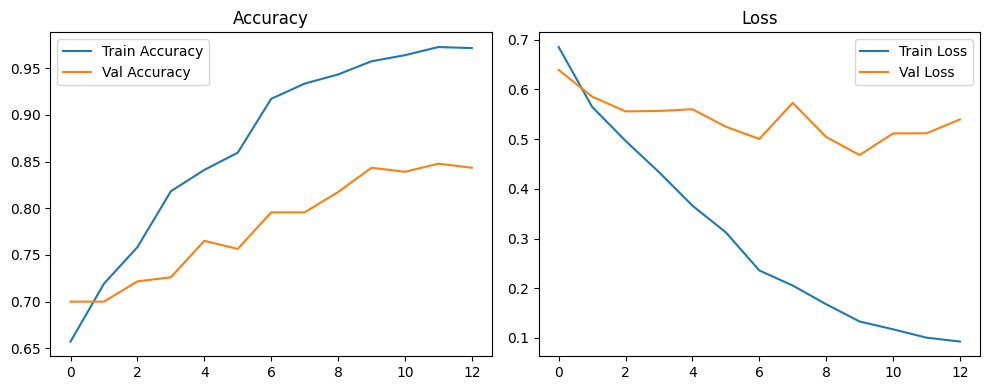

In [26]:
import matplotlib.pyplot as plt

# Accuracy curve
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],     label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [34]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_pred = (model.predict(X_val) > 0.5).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred))
print()
print("Classification Report:")
print(classification_report(y_val, y_pred, target_names=["CN", "AD/MCI"]))

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 171ms/step
Confusion Matrix:
[[ 49  24]
 [ 12 145]]

Classification Report:
              precision    recall  f1-score   support

          CN       0.80      0.67      0.73        73
      AD/MCI       0.86      0.92      0.89       157

    accuracy                           0.84       230
   macro avg       0.83      0.80      0.81       230
weighted avg       0.84      0.84      0.84       230



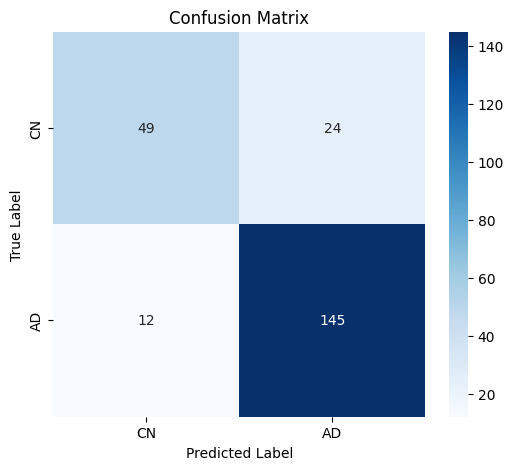

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Re-calculate confusion matrix as a good practice, though 'cm' is available in kernel state
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["CN", "AD"], yticklabels=["CN", "AD"])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [38]:
model.save("/content/drive/MyDrive/Task2Brute_model.h5")
print("Model saved to Drive!")

Model saved to Drive!


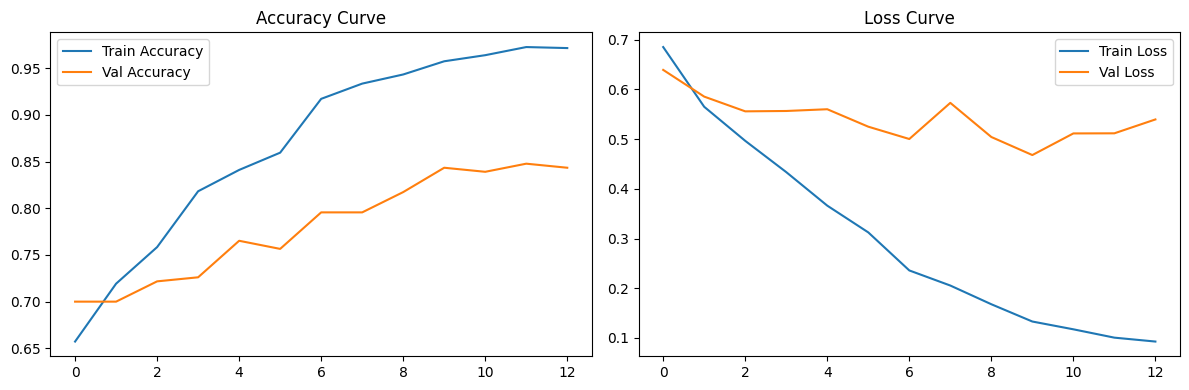

Plot saved!


AttributeError: 'list' object has no attribute 'download'

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],     label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Curve')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Curve')
plt.legend()

plt.tight_layout()
plt.savefig("/content/Task2_training_curves.png", dpi=150)
plt.show()
print("Plot saved!")

files.download("/content/Task2_training_curves.png")

In [40]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, balanced_accuracy_score
import numpy as np

y_pred_probs = model.predict(X_val)
y_pred       = (y_pred_probs > 0.5).astype(int)

bal_acc = balanced_accuracy_score(y_val, y_pred)
auc     = roc_auc_score(y_val, y_pred_probs)
cm      = confusion_matrix(y_val, y_pred)
report  = classification_report(y_val, y_pred, target_names=["CN", "AD"])

print("=============================")
print("TASK 2 — EVALUATION REPORT")
print("=============================")
print(f"Balanced Accuracy : {bal_acc:.4f}")
print(f"AUC-ROC           : {auc:.4f}")
print()
print("Confusion Matrix:")
print(cm)
print()
print("Classification Report:")
print(report)

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 283ms/step
TASK 2 — EVALUATION REPORT
Balanced Accuracy : 0.7974
AUC-ROC           : 0.8515

Confusion Matrix:
[[ 49  24]
 [ 12 145]]

Classification Report:
              precision    recall  f1-score   support

          CN       0.80      0.67      0.73        73
          AD       0.86      0.92      0.89       157

    accuracy                           0.84       230
   macro avg       0.83      0.80      0.81       230
weighted avg       0.84      0.84      0.84       230

